## Mall Customer Segmentation — clustering loyihasi

Bu safar do'kon mijozlari ustida ishlayman. Maqsad — mijozlarni guruhlarga ajratish (masalan kim ko'p xarid qiladi, kim kam). Bu safar `y` (javob) yo'q, model o'zi o'xshash mijozlarni topishi kerak.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = '/content/drive/MyDrive/ML_Projects/Klastering/mall_customers'

df = pd.read_csv(f'{path}/Mall_Customers.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Avval dataga umumiy nazar tashlayman — nechta qator, qaysi ustunlar bor.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Yosh, daromad va xarajat ko'rsatkichining statistikasi.

In [17]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Bo'sh joy bor-yo'qligini tekshirib olaman.

In [18]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Yillik daromad bilan xarajat ko'rsatkichini chizib ko'raman — shunchaki ko'z bilan qanday naqsh borligini ko'rish uchun.

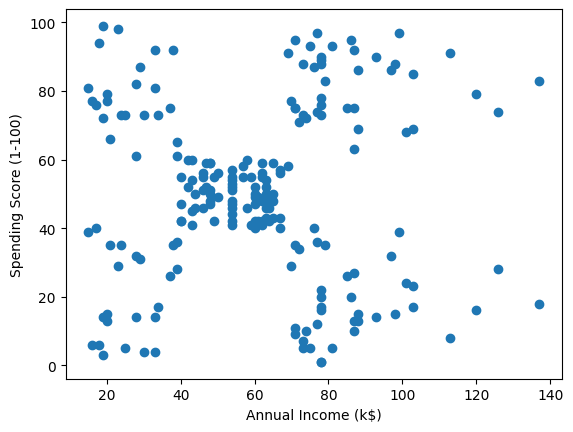

In [19]:
import matplotlib.pyplot as plt

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

Klasterlash uchun shu ikkita ustunni olaman, chunki grafikda aynan shularda guruhlar ko'rinib turibdi.

In [20]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

Nechta klaster kerakligini bilmayman, shuning uchun 1 dan 10 gacha sinab, har birida "inertia"ni yozib boraman (elbow method).

In [21]:
from sklearn.cluster import KMeans

inertia_list = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X)
  inertia_list.append(kmeans.inertia_)

Grafikka qarab qaysi nuqtada egri chiziq "tirsak" hosil qilishini ko'raman — o'sha optimal klaster soni bo'ladi.

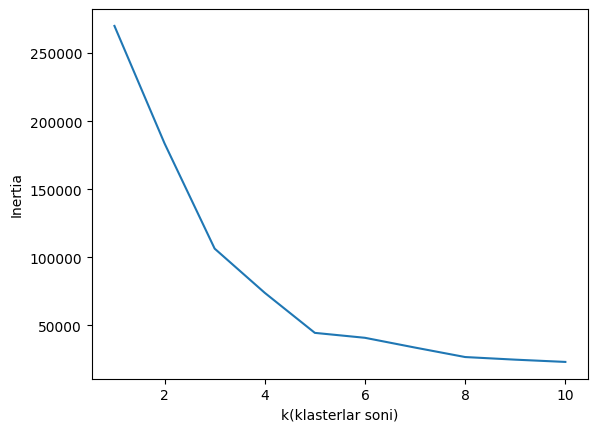

In [22]:
plt.plot(range(1,11),inertia_list)
plt.xlabel("k(klasterlar soni)")
plt.ylabel("Inertia")
plt.show()

Grafikdan k=5 chiqdi, shuning bilan yakuniy modelni quraman va har bir mijozga klaster raqamini yozib qo'yaman.

In [23]:
kmeans2 = KMeans(n_clusters=5, random_state=42)
kmeans2.fit(X)
df["Cluster"] = kmeans2.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Endi klasterlarni rang bilan ko'rsatib chizaman — natija qanday chiqqanini ko'rish uchun.

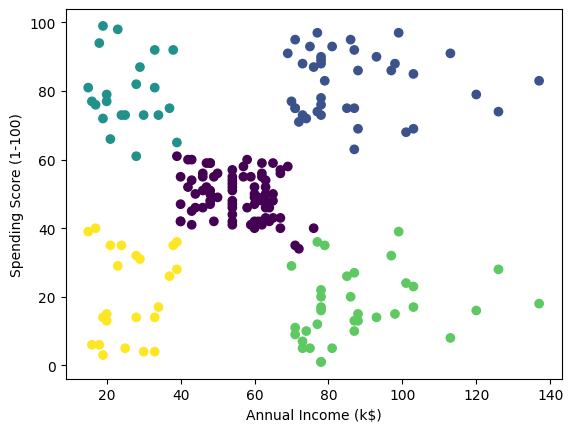

In [24]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

## Xulosa

Elbow method 5 ta klasterni ko'rsatdi, va K-Means natijasi ham xuddi grafikda ko'zim bilan ko'rgan guruhlarga to'g'ri keldi. Besh guruh taxminan shunday chiqdi:

- Daromadi past, xarajati ham past — tejamkor mijozlar
- Daromadi past, xarajati yuqori — kam pul bilan ko'p xarid qiladigan qiziq guruh
- Daromadi o'rtacha, xarajati ham o'rtacha — eng katta va "oddiy" guruh
- Daromadi yuqori, xarajati past — puli bor, lekin ko'p xarid qilmaydi
- Daromadi yuqori, xarajati ham yuqori — do'kon uchun eng qimmatli mijozlar

Bu guruhlarni bilish real hayotda foydali — masalan yuqori daromadli lekin kam xarid qiladigan guruhga alohida marketing qilish mumkin, yoki eng qimmatli mijozlarni maxsus dastur bilan ushlab qolish mumkin.